In [6]:
cd ..

/Users/madhavmundada/Downloads


Years found: [2020, 2021, 2022, 2023, 2024, 2025]
Loaded: {2020: (374755, 726726), 2021: (422976, 824929), 2022: (405184, 793782), 2023: (409377, 800479), 2024: (414295, 810242), 2025: (325312, 633665)}


/var/folders/zg/5ptr90zx58g1ckksp_kddn8c0000gn/T/ipykernel_76867/1141307506.py:142: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  c_merge[time_col] = pd.to_datetime(c_merge[time_col], errors="coerce")


cp_all shape: (4589823, 11)
c_merge shape: (2351899, 78)


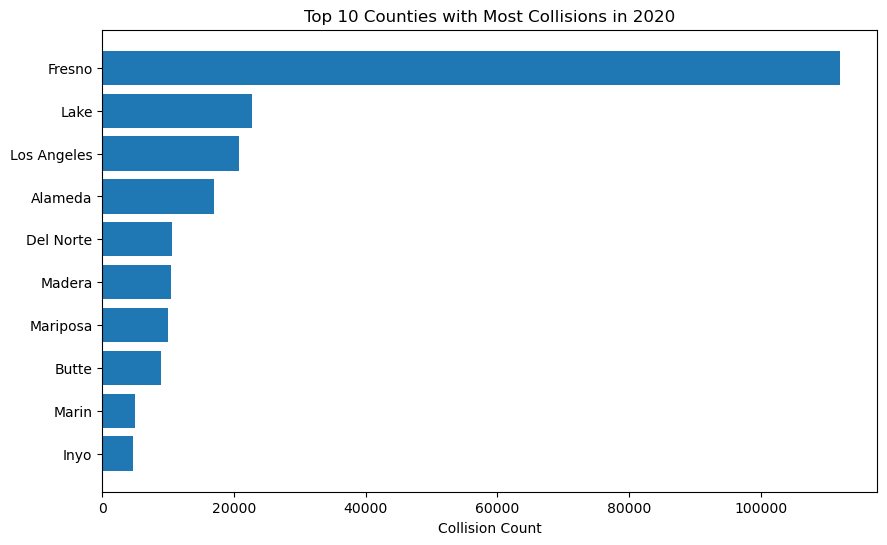

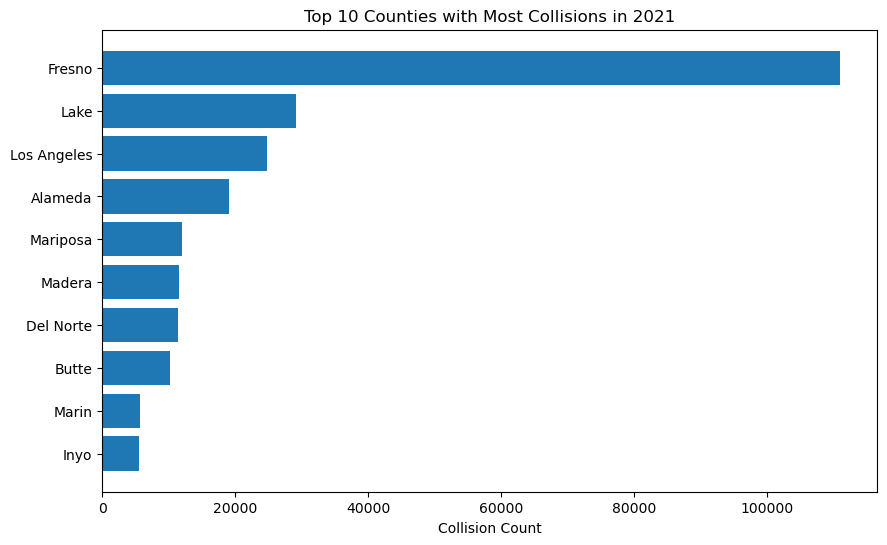

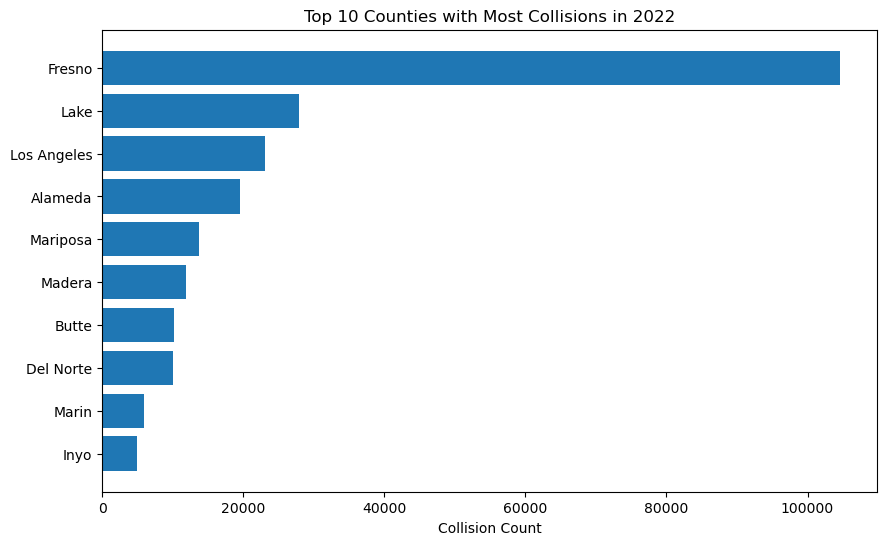

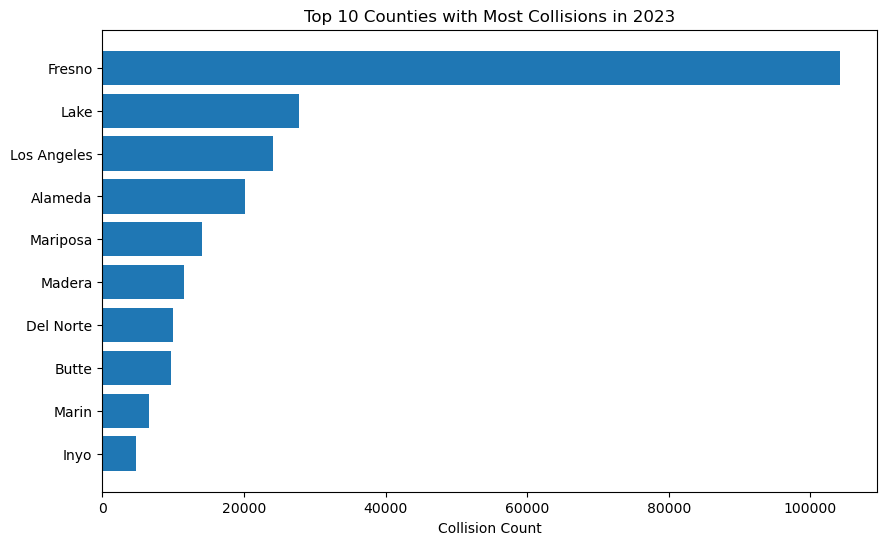

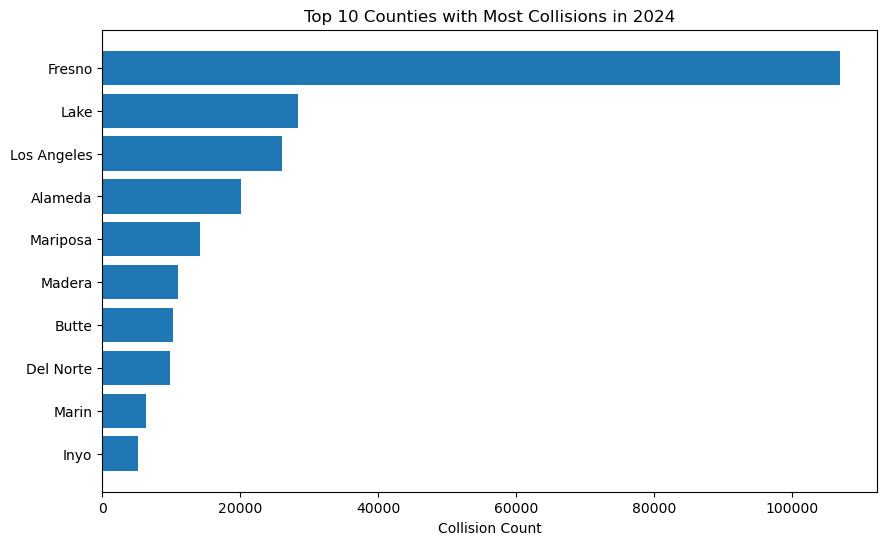

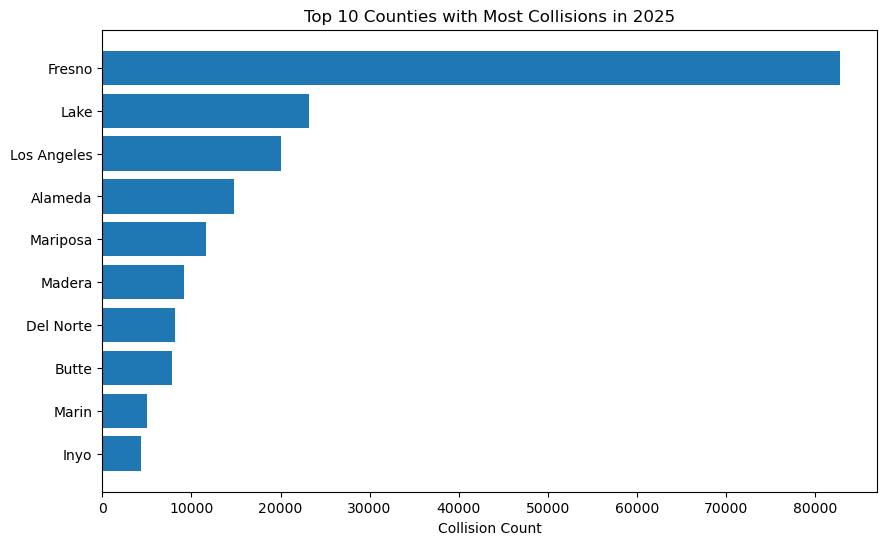

,County_Name,avg_severity
18,Los Angeles,0.828728
6,Contra Costa,0.812182
25,Mono,0.721425
21,Mariposa,0.688384
8,El Dorado,0.665192
22,Mendocino,0.654329
1,Alpine,0.645240
7,Del Norte,0.642514
24,Modoc,0.638223
15,Kings,0.634252


Age_Group
NaN      2002930
36–50     681781
26–35     637673
18–25     526365
51–65     480907
65+       209405
0–17       50762
Name: count, dtype: int64

In [8]:
# =========================
# 0) Setup
# =========================
from pathlib import Path
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ← change ONLY if your folder is different
DATA_DIR = Path("/Users/madhavmundada/Downloads/data")

# Discover available years from the folder (e.g., 2020…2025)
file_years = sorted({
    int(m.group(1))
    for p in DATA_DIR.glob("*_Crashes.csv")
    for m in [re.search(r"(\d{4})_Crashes\.csv$", p.name)]
    if m
})
YEARS = file_years or [2020, 2021, 2022, 2023, 2024, 2025]

print("Years found:", YEARS)

# County code → name (used if County_Code exists)
county_map = {
    1:"Alameda",3:"Alpine",5:"Amador",7:"Butte",9:"Calaveras",11:"Colusa",13:"Contra Costa",
    15:"Del Norte",17:"El Dorado",19:"Fresno",21:"Glenn",23:"Humboldt",25:"Imperial",27:"Inyo",
    29:"Kern",31:"Kings",33:"Lake",35:"Lassen",37:"Los Angeles",39:"Madera",41:"Marin",43:"Mariposa",
    45:"Mendocino",47:"Merced",49:"Modoc",51:"Mono",53:"Monterey",55:"Napa",57:"Nevada",59:"Orange",
    61:"Placer",63:"Plumas",65:"Riverside",67:"Sacramento",69:"San Benito",71:"San Bernardino",
    73:"San Diego",75:"San Francisco",77:"San Joaquin",79:"San Luis Obispo",81:"San Mateo",
    83:"Santa Barbara",85:"Santa Clara",87:"Santa Cruz",89:"Shasta",91:"Sierra",93:"Siskiyou",
    95:"Solano",97:"Sonoma",99:"Stanislaus",101:"Sutter",103:"Tehama",105:"Trinity",107:"Tulare",
    109:"Tuolumne",111:"Ventura",113:"Yolo",115:"Yuba"
}

# =========================
# 1) Helpers
# =========================
def read_csv_safe(path):
    # You can add `dtype=...` here if you want IDs as strings
    return pd.read_csv(path, low_memory=False, on_bad_lines='skip')

def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.rename(columns=lambda c: c.strip().replace(" ", "_").replace("/", "_"))
    return df

def standardize_collision_id(df: pd.DataFrame) -> pd.DataFrame:
    # Make sure we end up with a single "CollisionId" column no matter the original name
    candidates = ["CollisionId", "Collision_ID", "Collision_Id", "Collision id", "CollisionID"]
    for c in candidates:
        if c in df.columns:
            if c != "CollisionId":
                df = df.rename(columns={c: "CollisionId"})
            break
    return df

def coerce_int(series, default=np.nan):
    return pd.to_numeric(series, errors="coerce").fillna(default)

# =========================
# 2) Load per year (Year_Crashes.csv & Year_Parties.csv)
# =========================
crashes_by_year = {}
parties_by_year  = {}

for y in YEARS:
    c_path = DATA_DIR / f"{y}_Crashes.csv"
    p_path = DATA_DIR / f"{y}_Parties.csv"

    if not c_path.exists():
        raise FileNotFoundError(f"Missing file: {c_path}")
    if not p_path.exists():
        raise FileNotFoundError(f"Missing file: {p_path}")

    c_df = read_csv_safe(c_path)
    p_df = read_csv_safe(p_path)

    c_df = normalize_columns(c_df)
    p_df = normalize_columns(p_df)

    c_df = standardize_collision_id(c_df)
    p_df = standardize_collision_id(p_df)

    crashes_by_year[y] = c_df
    parties_by_year[y] = p_df

print("Loaded:", {y: (len(crashes_by_year[y]), len(parties_by_year[y])) for y in YEARS})

# =========================
# 3) Merge Parties→Crashes per year + build unions
# =========================
cp_by_year = {}
for y in YEARS:
    c = crashes_by_year[y]
    p = parties_by_year[y]
    if "CollisionId" not in p.columns or "CollisionId" not in c.columns:
        missing = [name for name, df in [("Parties", p), ("Crashes", c)] if "CollisionId" not in df.columns]
        raise KeyError(f"{y}: CollisionId missing in {', '.join(missing)}")

    cp = p.merge(c, on="CollisionId", how="left", suffixes=("_party","_crash"))
    cp["Year"] = y

    # County name if available
    if "County_Code" in cp.columns:
        cp["County_Name"] = cp["County_Code"].map(county_map)

    # Severity score (injured + killed) if columns exist
    ni = cp.columns[cp.columns.str.fullmatch(r"NumberInjured(_party|_crash)?")]
    nk = cp.columns[cp.columns.str.fullmatch(r"NumberKilled(_party|_crash)?")]
    inj = coerce_int(cp[ni[0]]) if len(ni) else 0
    kil = coerce_int(cp[nk[0]]) if len(nk) else 0
    cp["Severity_Score"] = inj + kil

    cp_by_year[y] = cp

# Keep a consistent subset if present
COLS_KEEP = [
    "CollisionId","PartyId","GenderDescription","StatedAge","County_Code",
    "County_Name","City_Name","NumberInjured","NumberKilled","Severity_Score","Year"
]

def take_cols(df, cols):
    return df[[c for c in cols if c in df.columns]].copy()

cp_all = pd.concat([take_cols(cp_by_year[y], COLS_KEEP) for y in YEARS], ignore_index=True)

# Also build crashes-only union for time-based plots
c_merge = pd.concat([crashes_by_year[y].assign(Year=y) for y in YEARS], ignore_index=True)

# =========================
# 4) Datetime derivation (robust to different column names)
# =========================
# Try common crash date/time column variants
time_candidates = [
    "Crash_Date_Time", "CrashDateTime", "Crash_Date", "Collision_Date",
    "Crash Date Time", "CollisionDate", "DateTime", "Date_Time"
]
time_col = next((c for c in time_candidates if c in c_merge.columns), None)

if time_col:
    c_merge[time_col] = pd.to_datetime(c_merge[time_col], errors="coerce")
    c_merge["Hour"] = c_merge[time_col].dt.hour
    c_merge["DayOfWeek"] = c_merge[time_col].dt.day_name()

# Ensure County_Name exists on crashes table as well (for plots)
if "County_Name" not in c_merge.columns and "County_Code" in c_merge.columns:
    c_merge["County_Name"] = c_merge["County_Code"].map(county_map)

# =========================
# 5) Example outputs (quick checks + a few plots)
# =========================
print("cp_all shape:", cp_all.shape)
print("c_merge shape:", c_merge.shape)

# A) Top-10 counties per year by collision count
collisions_by_year_county = (
    c_merge.groupby(["Year","County_Name"]).size().reset_index(name="num_collisions")
)

def top10_plot_for_year(y):
    dfy = (collisions_by_year_county[collisions_by_year_county["Year"]==y]
           .sort_values("num_collisions", ascending=False)
           .head(10))
    plt.figure(figsize=(10,6))
    plt.barh(dfy["County_Name"], dfy["num_collisions"])
    plt.gca().invert_yaxis()
    plt.title(f"Top 10 Counties with Most Collisions in {y}")
    plt.xlabel("Collision Count")
    plt.show()

for y in YEARS:
    top10_plot_for_year(y)

# B) Severity by county (quick sanity table)
if "County_Name" in cp_all.columns and "Severity_Score" in cp_all.columns:
    severity_by_county = (cp_all.groupby("County_Name")["Severity_Score"]
                              .mean()
                              .reset_index(name="avg_severity")
                              .sort_values("avg_severity", ascending=False))
    display(severity_by_county.head(15))

# C) Optional: Age buckets if StatedAge is present
if "StatedAge" in cp_all.columns:
    bins = [0,17,25,35,50,65,120]
    labels = ["0–17","18–25","26–35","36–50","51–65","65+"]
    cp_all["Age_Group"] = pd.cut(pd.to_numeric(cp_all["StatedAge"], errors="coerce"),
                                 bins=bins, labels=labels, right=True)
    display(cp_all["Age_Group"].value_counts(dropna=False))

In [9]:
# Basic info
cp_all.info()
cp_all.head()

# Check for missing CollisionIds or duplicates
cp_all['CollisionId'].isna().sum(), cp_all['CollisionId'].duplicated().sum()

# Check which years and counties are covered
cp_all['Year'].value_counts()
cp_all['County_Name'].value_counts().head(20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4589823 entries, 0 to 4589822
Data columns (total 12 columns):
 #   Column             Dtype   
---  ------             -----   
 0   CollisionId        int64   
 1   PartyId            int64   
 2   GenderDescription  object  
 3   StatedAge          float64 
 4   County_Code        float64 
 5   County_Name        object  
 6   City_Name          object  
 7   NumberInjured      float64 
 8   NumberKilled       float64 
 9   Severity_Score     float64 
 10  Year               int64   
 11  Age_Group          category
dtypes: category(1), float64(5), int64(3), object(3)
memory usage: 389.6+ MB


County_Name
Fresno          1287704
Lake             305520
Los Angeles      270654
Alameda          226710
Mariposa         149726
Madera           124912
Butte            111027
Del Norte        110898
Marin             67720
Inyo              54018
Kings             42226
Modoc             40907
Nevada            26212
Glenn             26023
Calaveras         19053
Mendocino         14805
Mono              11399
Humboldt          10643
Contra Costa      10432
Kern              10279
Name: count, dtype: int64

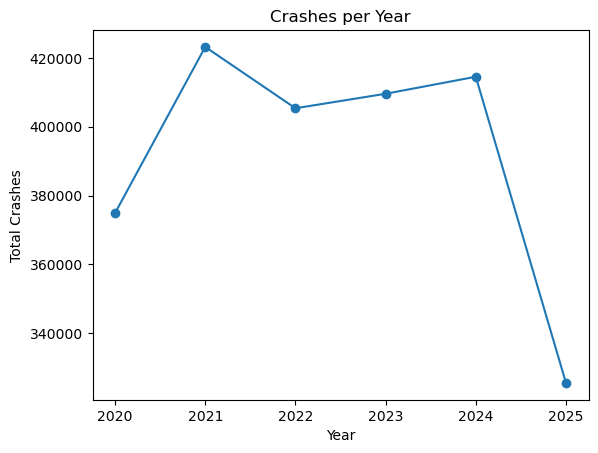

In [10]:
yearly = cp_all.groupby('Year')['CollisionId'].nunique().reset_index(name='Total_Crashes')
plt.plot(yearly['Year'], yearly['Total_Crashes'], marker='o')
plt.title("Crashes per Year")
plt.xlabel("Year")
plt.ylabel("Total Crashes")
plt.show()

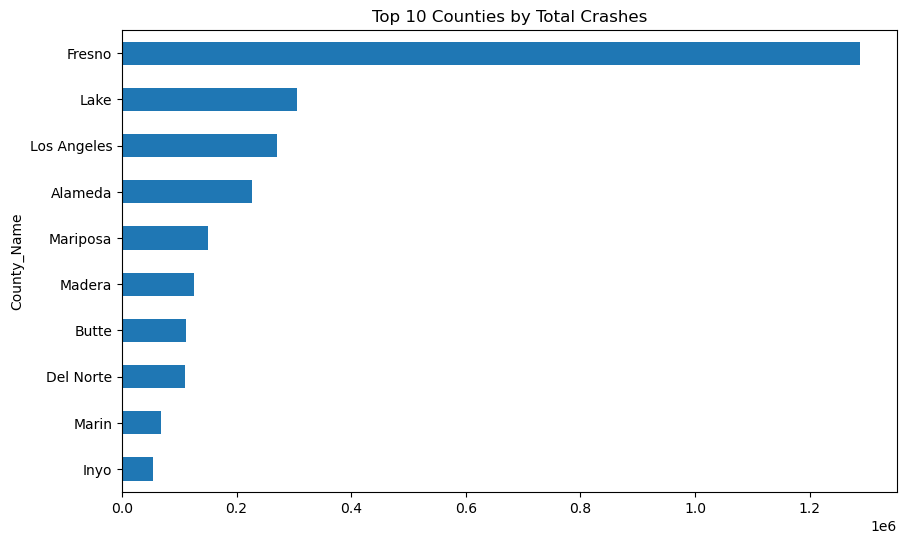

In [12]:
top_counties = cp_all['County_Name'].value_counts().head(10)
top_counties.plot(kind='barh', figsize=(10,6), title='Top 10 Counties by Total Crashes')
plt.gca().invert_yaxis()
plt.show()

/var/folders/zg/5ptr90zx58g1ckksp_kddn8c0000gn/T/ipykernel_76867/3018369640.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cp_all.groupby('Age_Group')['Severity_Score'].mean().plot(kind='bar')


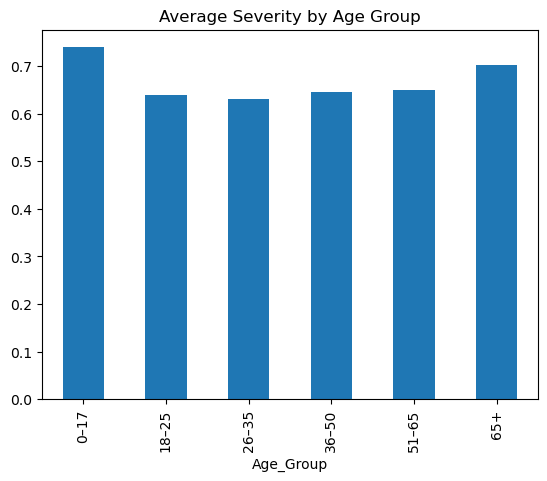

In [13]:
cp_all.groupby('Age_Group')['Severity_Score'].mean().plot(kind='bar')
plt.title('Average Severity by Age Group')
plt.show()

In [16]:
# Save both merged datasets as CSVs
cp_all.to_csv("merged_cp_all.csv", index=False)
c_merge.to_csv("merged_c_merge.csv", index=False)

In [17]:
from pathlib import Path
import re
import pandas as pd

# Folder where all yearly CSVs are stored
DATA_DIR = Path("/Users/madhavmundada/Downloads/data")

# Detect all "Parties" files
party_files = sorted(DATA_DIR.glob("*_Parties.csv"))
print(f"Found {len(party_files)} party files:")
for f in party_files:
    print(" -", f.name)

# Helper to normalize column names
def normalize_columns(df):
    return df.rename(columns=lambda c: c.strip().replace(" ", "_").replace("/", "_"))

# Read and tag each Parties file with its year
p_dfs = []
for path in party_files:
    # extract the year from the filename, e.g., 2020_Parties.csv → 2020
    m = re.search(r"(\d{4})_Parties\.csv$", path.name)
    year = int(m.group(1)) if m else None

    df = pd.read_csv(path, low_memory=False, on_bad_lines='skip')
    df = normalize_columns(df)
    df["Year"] = year  # add year column for identification
    p_dfs.append(df)

# Concatenate all into one
p_merge = pd.concat(p_dfs, ignore_index=True)
print("Merged parties shape:", p_merge.shape)

# Optional: ensure consistent CollisionId naming
for col in ["Collision_ID", "Collision_Id", "Collision id"]:
    if col in p_merge.columns and "CollisionId" not in p_merge.columns:
        p_merge.rename(columns={col: "CollisionId"}, inplace=True)

# Save to CSV
p_merge.to_csv("merged_p_merge.csv", index=False)
print("✅ Saved merged parties data as merged_p_merge.csv")

Found 6 party files:
 - 2020_Parties.csv
 - 2021_Parties.csv
 - 2022_Parties.csv
 - 2023_Parties.csv
 - 2024_Parties.csv
 - 2025_Parties.csv
Merged parties shape: (4589823, 49)
✅ Saved merged parties data as merged_p_merge.csv


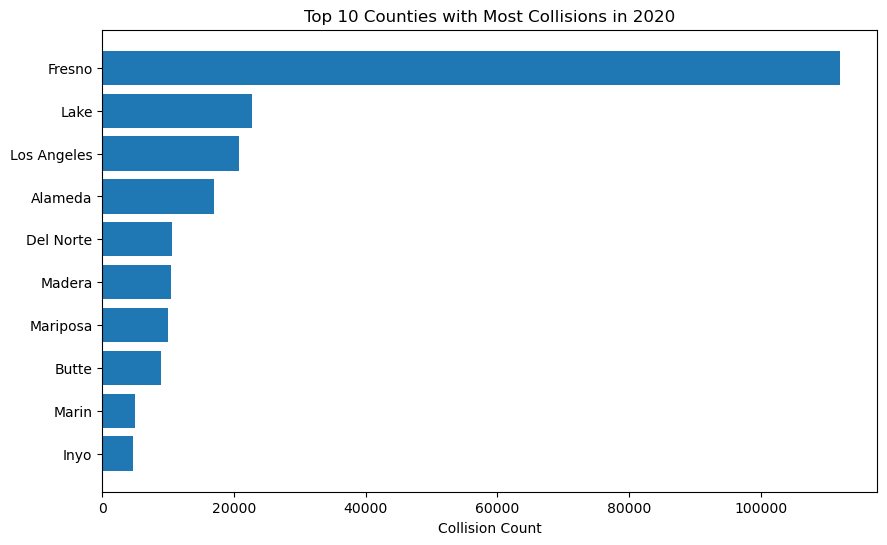

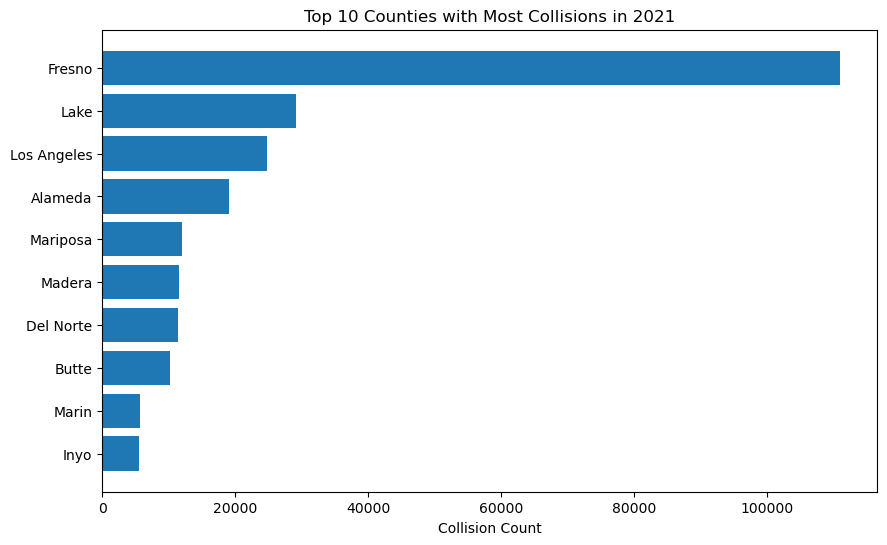

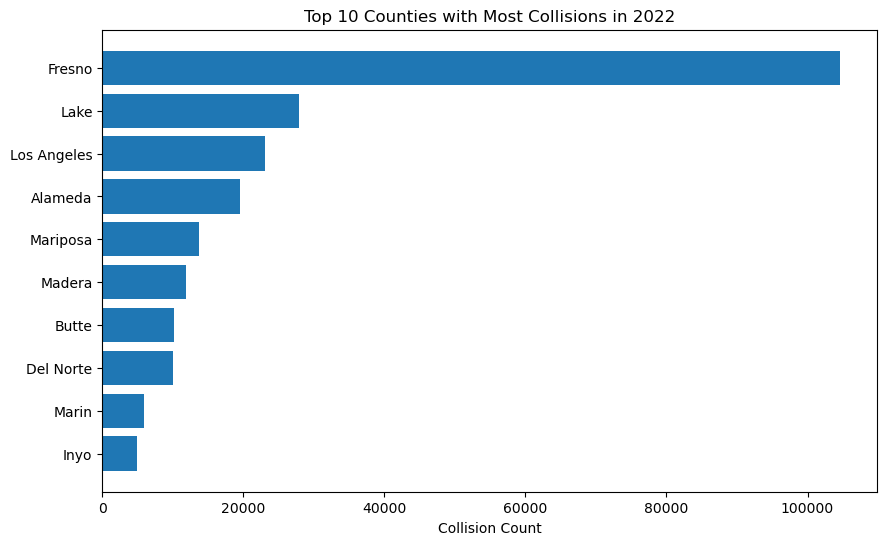

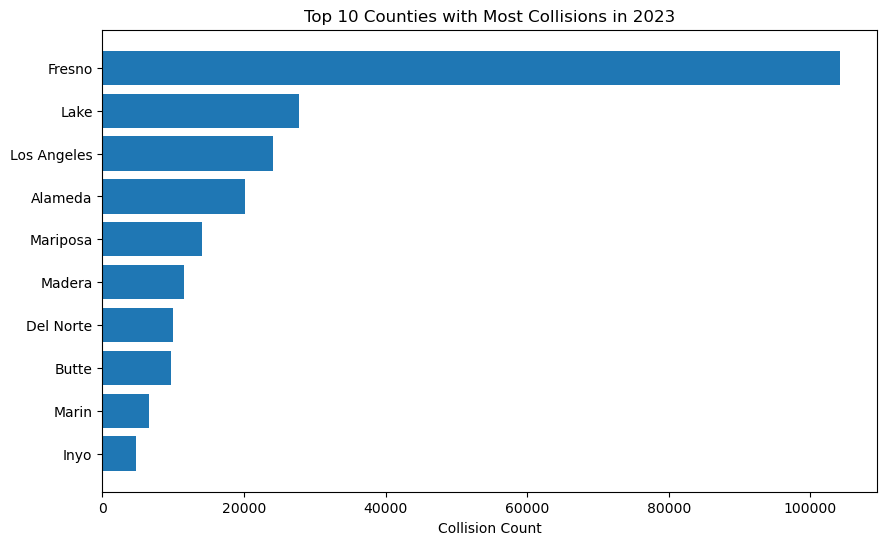

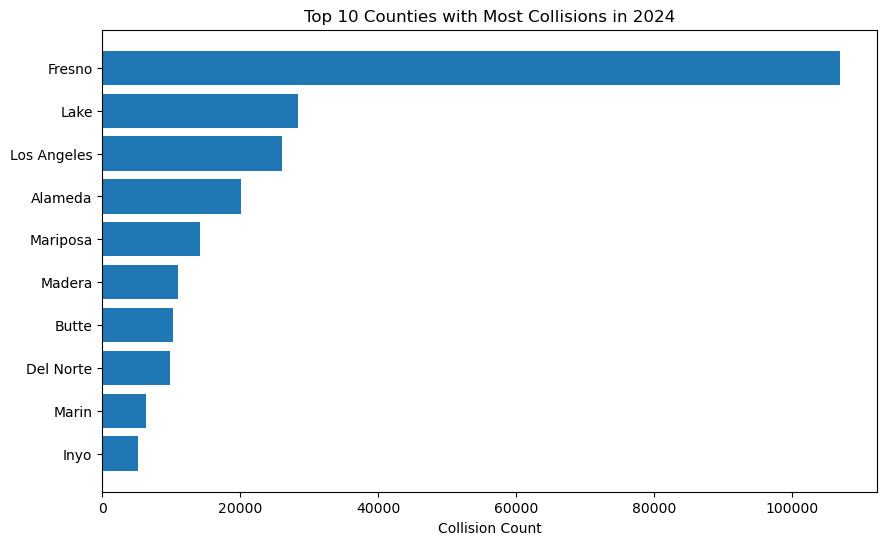

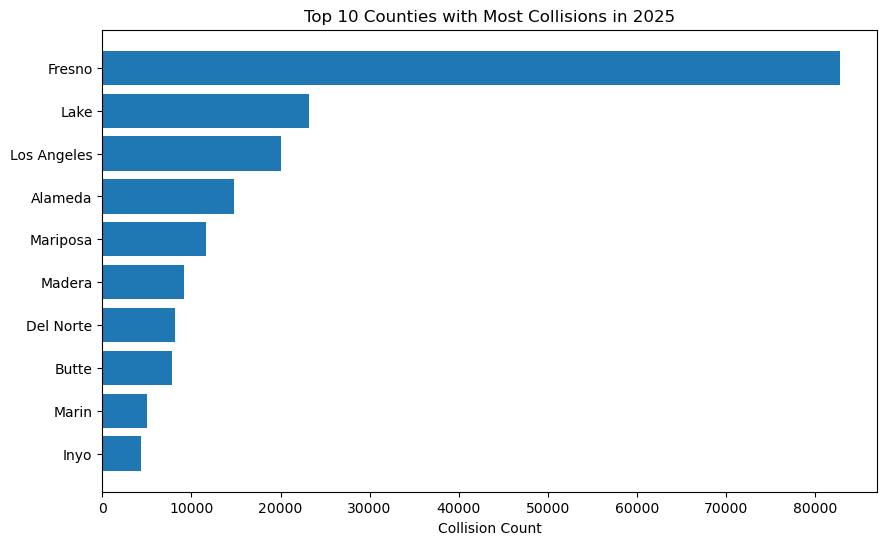

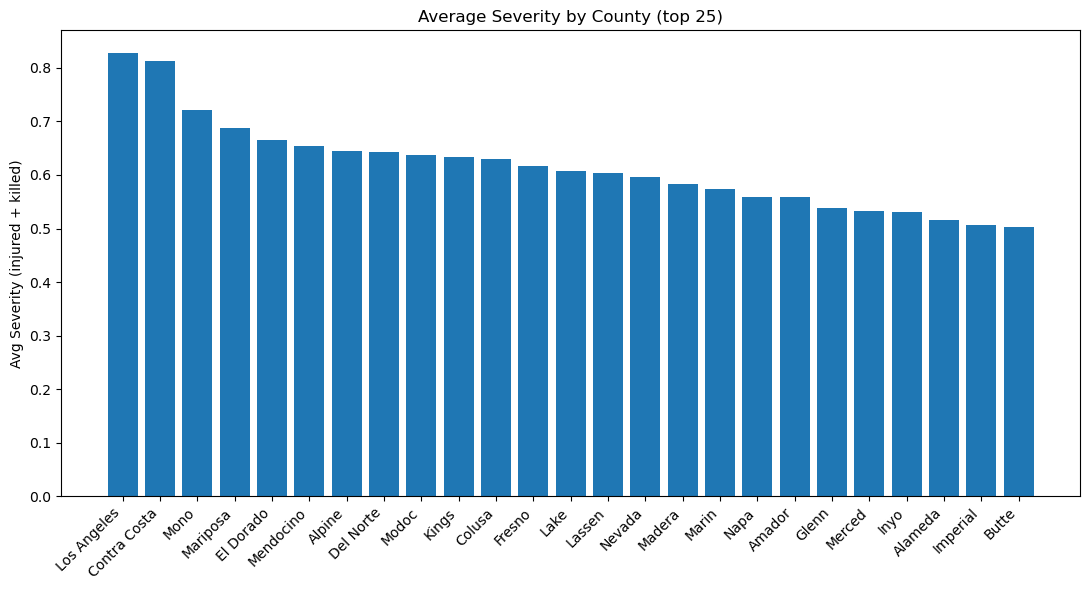

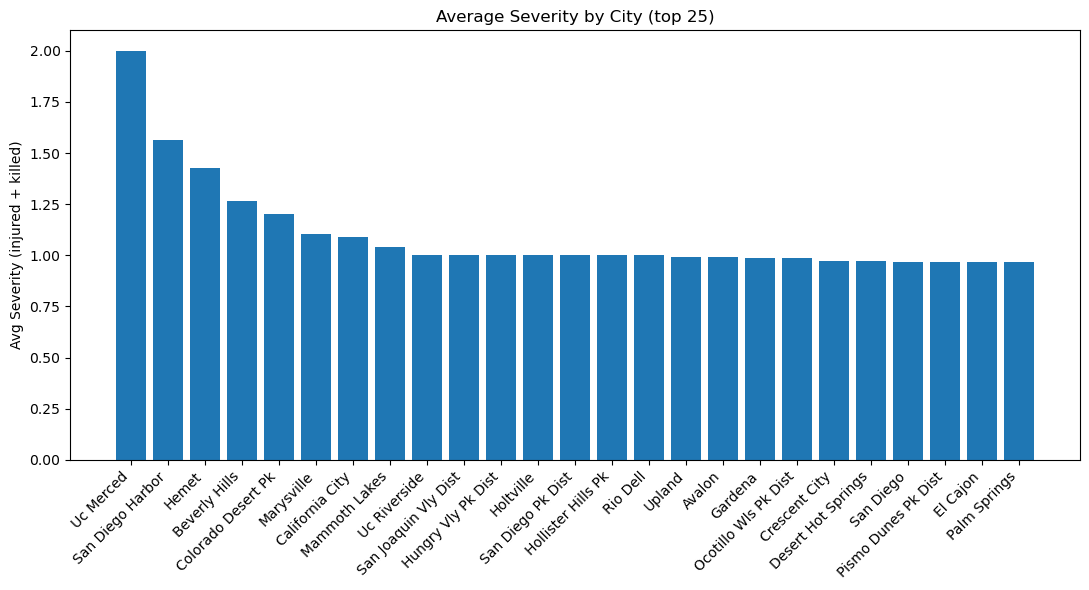

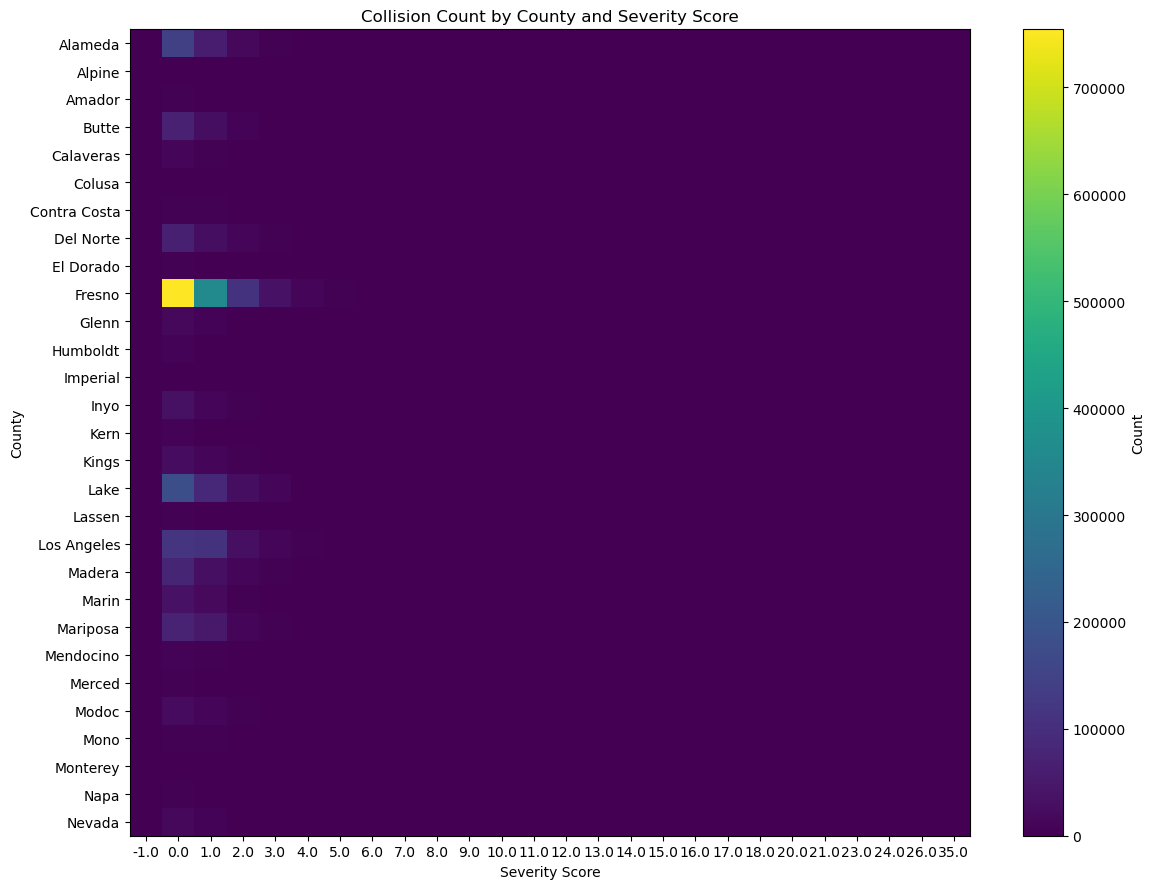

GenderDescription,FEMALE,MALE,NON-BINARY,UNKNOWN
County_Name,,,,
Alameda,61097,120766,65,3959
Alpine,1364,2477,1,35
Amador,1700,3029,2,44
Butte,33656,57123,51,3172
Calaveras,5849,11048,6,266
Colusa,700,1553,0,44
Contra Costa,3099,6423,2,70
Del Norte,30388,56217,80,6354
El Dorado,2457,4342,0,111


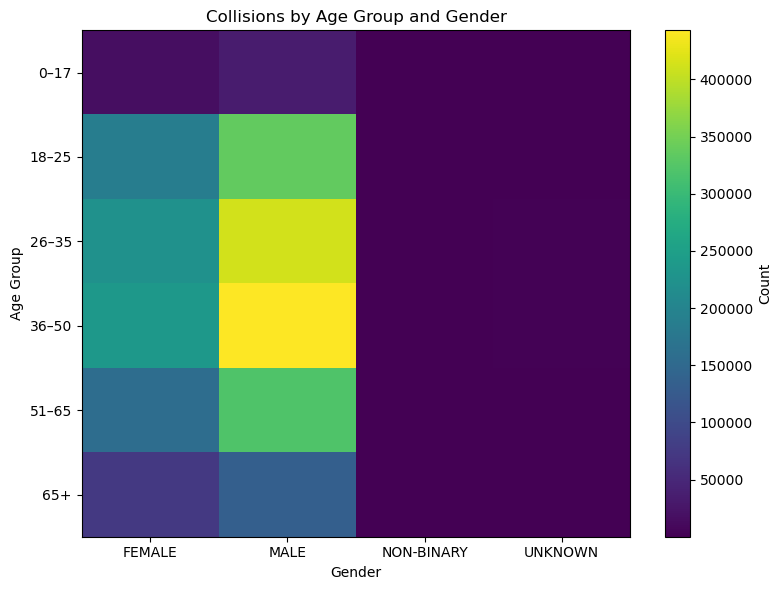

In [18]:
# =========================
# 0) Setup + load the merged CSVs
# =========================
from pathlib import Path
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# If you saved them somewhere else, change these:
CP_PATH = Path("merged_cp_all.csv")
C_PATH  = Path("merged_c_merge.csv")

cp_all = pd.read_csv(CP_PATH, low_memory=False)
c_merge = pd.read_csv(C_PATH, low_memory=False)

# Normalize column names (handles spacing/slashes from raw files)
cp_all.columns = (cp_all.columns.str.strip().str.replace(" ", "_").str.replace("/", "_"))
c_merge.columns = (c_merge.columns.str.strip().str.replace(" ", "_").str.replace("/", "_"))

# Convenience: ensure Severity_Score exists on cp_all
if "Severity_Score" not in cp_all.columns:
    ni = [c for c in cp_all.columns if c.lower().startswith("numberinjured")]
    nk = [c for c in cp_all.columns if c.lower().startswith("numberkilled")]
    inj = pd.to_numeric(cp_all[ni[0]], errors="coerce") if ni else 0
    kil = pd.to_numeric(cp_all[nk[0]], errors="coerce") if nk else 0
    cp_all["Severity_Score"] = inj.fillna(0) + kil.fillna(0)

# Convenience: County_Name on crashes, if only County_Code exists
county_map = {
    1:"Alameda",3:"Alpine",5:"Amador",7:"Butte",9:"Calaveras",11:"Colusa",13:"Contra Costa",15:"Del Norte",
    17:"El Dorado",19:"Fresno",21:"Glenn",23:"Humboldt",25:"Imperial",27:"Inyo",29:"Kern",31:"Kings",33:"Lake",
    35:"Lassen",37:"Los_Angeles",39:"Madera",41:"Marin",43:"Mariposa",45:"Mendocino",47:"Merced",49:"Modoc",
    51:"Mono",53:"Monterey",55:"Napa",57:"Nevada",59:"Orange",61:"Placer",63:"Plumas",65:"Riverside",
    67:"Sacramento",69:"San_Benito",71:"San_Bernardino",73:"San_Diego",75:"San_Francisco",77:"San_Joaquin",
    79:"San_Luis_Obispo",81:"San_Mateo",83:"Santa_Barbara",85:"Santa_Clara",87:"Santa_Cruz",89:"Shasta",
    91:"Sierra",93:"Siskiyou",95:"Solano",97:"Sonoma",99:"Stanislaus",101:"Sutter",103:"Tehama",
    105:"Trinity",107:"Tulare",109:"Tuolumne",111:"Ventura",113:"Yolo",115:"Yuba"
}
if "County_Name" not in c_merge.columns and "County_Code" in c_merge.columns:
    c_merge["County_Name"] = c_merge["County_Code"].map(county_map)

# Time columns: find one and derive Hour/DayOfWeek if missing
time_candidates = ["Crash_Date_Time","CrashDateTime","Crash_Date","Collision_Date","Date_Time","DateTime"]
time_col = next((c for c in time_candidates if c in c_merge.columns), None)
if time_col:
    c_merge[time_col] = pd.to_datetime(c_merge[time_col], errors="coerce")
    if "Hour" not in c_merge.columns:
        c_merge["Hour"] = c_merge[time_col].dt.hour
    if "DayOfWeek" not in c_merge.columns:
        c_merge["DayOfWeek"] = c_merge[time_col].dt.day_name()

# =========================
# 1) Top-10 counties per year (2020–2025)
# =========================
if "Year" in c_merge.columns and "County_Name" in c_merge.columns:
    collisions_yearly = (
        c_merge.groupby(["Year","County_Name"])
               .size()
               .reset_index(name="num_collisions")
               .sort_values(["Year","num_collisions"], ascending=[True,False])
    )

    years = sorted(c_merge["Year"].dropna().unique().astype(int).tolist())
    for y in years:
        top10 = collisions_yearly.query("Year == @y").head(10)
        plt.figure(figsize=(10,6))
        plt.barh(top10["County_Name"], top10["num_collisions"])
        plt.gca().invert_yaxis()
        plt.title(f"Top 10 Counties with Most Collisions in {y}")
        plt.xlabel("Collision Count")
        plt.show()

# =========================
# 2) Average severity by county and by city (from cp_all)
# =========================
if "Severity_Score" in cp_all.columns:
    if "County_Name" in cp_all.columns:
        sev_by_county = (
            cp_all.groupby("County_Name")["Severity_Score"]
                  .mean()
                  .reset_index(name="avg_severity")
                  .sort_values("avg_severity", ascending=False)
        )
        plt.figure(figsize=(11,6))
        plt.bar(sev_by_county["County_Name"].head(25), sev_by_county["avg_severity"].head(25))
        plt.xticks(rotation=45, ha="right")
        plt.title("Average Severity by County (top 25)")
        plt.ylabel("Avg Severity (injured + killed)")
        plt.tight_layout()
        plt.show()

    if "City_Name" in cp_all.columns:
        sev_by_city = (
            cp_all.groupby("City_Name")["Severity_Score"]
                  .mean()
                  .reset_index(name="avg_severity")
                  .sort_values("avg_severity", ascending=False)
        )
        plt.figure(figsize=(11,6))
        plt.bar(sev_by_city["City_Name"].head(25), sev_by_city["avg_severity"].head(25))
        plt.xticks(rotation=45, ha="right")
        plt.title("Average Severity by City (top 25)")
        plt.ylabel("Avg Severity (injured + killed)")
        plt.tight_layout()
        plt.show()

# =========================
# 3) County × Severity_Score heatmap (counts)
# =========================
if {"County_Name","Severity_Score"}.issubset(cp_all.columns):
    heat_df = (cp_all.groupby(["County_Name","Severity_Score"]).size().unstack(fill_value=0))
    # Keep a consistent severity range if numeric-like
    cols_sorted = sorted([c for c in heat_df.columns if isinstance(c,(int,float,np.integer,np.floating))])
    mat = heat_df[cols_sorted].to_numpy() if cols_sorted else heat_df.to_numpy()

    plt.figure(figsize=(12,9))
    plt.imshow(mat, aspect="auto")
    plt.colorbar(label="Count")
    plt.title("Collision Count by County and Severity Score")
    plt.xlabel("Severity Score")
    plt.ylabel("County")
    # axis ticks
    if cols_sorted:
        plt.xticks(ticks=range(len(cols_sorted)), labels=[str(x) for x in cols_sorted], rotation=0)
    plt.yticks(ticks=range(len(heat_df.index)), labels=heat_df.index)
    plt.tight_layout()
    plt.show()

# =========================
# 4) Gender tables + Age×Gender heatmap
# =========================
if {"County_Name","GenderDescription"}.issubset(cp_all.columns):
    gender_by_county = (cp_all.groupby(["County_Name","GenderDescription"]).size().unstack(fill_value=0))
    display(gender_by_county.head(20))  # big table; shows first 20 counties

if {"Age_Group","GenderDescription"}.issubset(cp_all.columns):
    age_gender = (
        cp_all.dropna(subset=["Age_Group","GenderDescription"])
              .groupby(["Age_Group","GenderDescription"])
              .size().unstack(fill_value=0)
    )
    plt.figure(figsize=(8,6))
    plt.imshow(age_gender.to_numpy(), aspect="auto")
    plt.colorbar(label="Count")
    plt.title("Collisions by Age Group and Gender")
    plt.xlabel("Gender")
    plt.ylabel("Age Group")
    plt.xticks(ticks=range(len(age_gender.columns)), labels=age_gender.columns, rotation=0)
    plt.yticks(ticks=range(len(age_gender.index)), labels=age_gender.index)
    plt.tight_layout()
    plt.show()

# =========================
# 5) Weather × Hour severity heatmap (from crashes)
# =========================
weather_col = next((c for c in ["Weather_1","Weather1","Weather","Weather_Condition","Weather__1","Weather_1_"] if c in c_merge.columns), None)
if weather_col and {"Hour","Severity"}.issubset(c_merge.columns):
    pivot = c_merge.pivot_table(values="Severity", index="Hour", columns=weather_col, aggfunc="mean")
    plt.figure(figsize=(12,6))
    plt.imshow(pivot.to_numpy(), aspect="auto")
    plt.colorbar(label="Average Severity")
    plt.title("Weather × Hour — Average Severity")
    plt.xlabel("Weather")
    plt.ylabel("Hour")
    plt.xticks(ticks=range(len(pivot.columns)), labels=[str(x) for x in pivot.columns], rotation=45, ha="right")
    plt.yticks(ticks=range(len(pivot.index)), labels=pivot.index)
    plt.tight_layout()
    plt.show()

# =========================
# 6) Severity by Lighting Condition (bars)
# =========================
light_col = next((c for c in ["Lighting","Lighting_Condition","Lighting_Conditions","Light_Condition"] if c in c_merge.columns), None)
if light_col and "Severity" in c_merge.columns:
    sev_light = c_merge.groupby(light_col)["Severity"].mean().sort_values(ascending=False).head(20)
    plt.figure(figsize=(12,5))
    plt.bar(sev_light.index, sev_light.values)
    plt.xticks(rotation=45, ha="right")
    plt.title("Severity by Lighting Condition (top 20)")
    plt.ylabel("Average Severity")
    plt.tight_layout()
    plt.show()

# =========================
# 7) Driver behaviors — most severe / most common (bars)
# =========================
# We’ll look for whichever of these columns exist in your crashes data.
behavior_candidates = [
    "Primary_Collision_Factor", "PCF_Violation_Code", "PCF_Violation_Category",
    "PCF_Violation_Description", "Driver_Action", "Driver_Action_Description",
    "Sobriety", "Sobriety_Description"
]
present_behaviors = [c for c in behavior_candidates if c in c_merge.columns]

if "Severity" in c_merge.columns and present_behaviors:
    # Most severe (mean severity)
    mean_tables = []
    for col in present_behaviors:
        m = (
            c_merge.groupby(col)["Severity"]
                   .mean()
                   .reset_index()
                   .rename(columns={col:"behavior_value", "Severity":"avg_severity"})
                   .assign(behavior_col=col)
        )
        mean_tables.append(m)
    mean_all = pd.concat(mean_tables, ignore_index=True).dropna(subset=["avg_severity"])
    top_mean = mean_all.sort_values("avg_severity", ascending=False).head(15)

    plt.figure(figsize=(12,6))
    plt.barh(top_mean["behavior_value"], top_mean["avg_severity"])
    plt.gca().invert_yaxis()
    plt.title("Driver Behaviors with Highest Average Severity (top 15)")
    plt.xlabel("Average Severity")
    plt.tight_layout()
    plt.show()

    # Most common (counts)
    count_tables = []
    for col in present_behaviors:
        cnt = (
            c_merge[col]
            .value_counts(dropna=False)
            .reset_index()
            .rename(columns={"index":"behavior_value", col:"count"})
            .assign(behavior_col=col)
        )
        count_tables.append(cnt)
    final_counts = pd.concat(count_tables, ignore_index=True)
    top_counts = final_counts.sort_values("count", ascending=False).head(15)

    plt.figure(figsize=(12,6))
    plt.barh(top_counts["behavior_value"], top_counts["count"])
    plt.gca().invert_yaxis()
    plt.title("Most Common Driver Behaviors (top 15)")
    plt.xlabel("Crash Count")
    plt.tight_layout()
    plt.show()

In [30]:
# =========================
# 0) Setup: imports, theme, load data
# =========================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# Paths (change if needed)
CP_PATH = Path("merged_cp_all.csv")
C_PATH  = Path("merged_c_merge.csv")

cp_all  = pd.read_csv(CP_PATH, low_memory=False)
c_merge = pd.read_csv(C_PATH, low_memory=False)

# Clean column names (robust to spacing/slashes)
cp_all.columns  = (cp_all.columns.str.strip().str.replace(" ", "_").str.replace("/", "_"))
c_merge.columns = (c_merge.columns.str.strip().str.replace(" ", "_").str.replace("/", "_"))

# Seaborn theme
sns.set_theme(style="whitegrid", context="talk")
sns.set_palette("deep")

# Helpers
def ensure_severity(df):
    if "Severity_Score" not in df.columns:
        ni = [c for c in df.columns if c.lower().startswith("numberinjured")]
        nk = [c for c in df.columns if c.lower().startswith("numberkilled")]
        inj = pd.to_numeric(df[ni[0]], errors="coerce") if ni else 0
        kil = pd.to_numeric(df[nk[0]], errors="coerce") if nk else 0
        df["Severity_Score"] = inj.fillna(0) + kil.fillna(0)

def ensure_datetime_parts(df):
    candidates = ["Crash_Date_Time","CrashDateTime","Crash_Date","Collision_Date","Date_Time","DateTime"]
    col = next((c for c in candidates if c in df.columns), None)
    if col:
        df[col] = pd.to_datetime(df[col], errors="coerce")
        if "Hour" not in df.columns:
            df["Hour"] = df[col].dt.hour
        if "DayOfWeek" not in df.columns:
            df["DayOfWeek"] = df[col].dt.day_name()

ensure_severity(cp_all)
ensure_datetime_parts(c_merge)

# Age group (create if missing)
if "Age_Group" not in cp_all.columns and "StatedAge" in cp_all.columns:
    cp_all["Age_Group"] = pd.cut(
        pd.to_numeric(cp_all["StatedAge"], errors="coerce"),
        bins=[0,17,25,35,50,65,120],
        labels=["0–17","18–25","26–35","36–50","51–65","65+"],
        right=True
    )

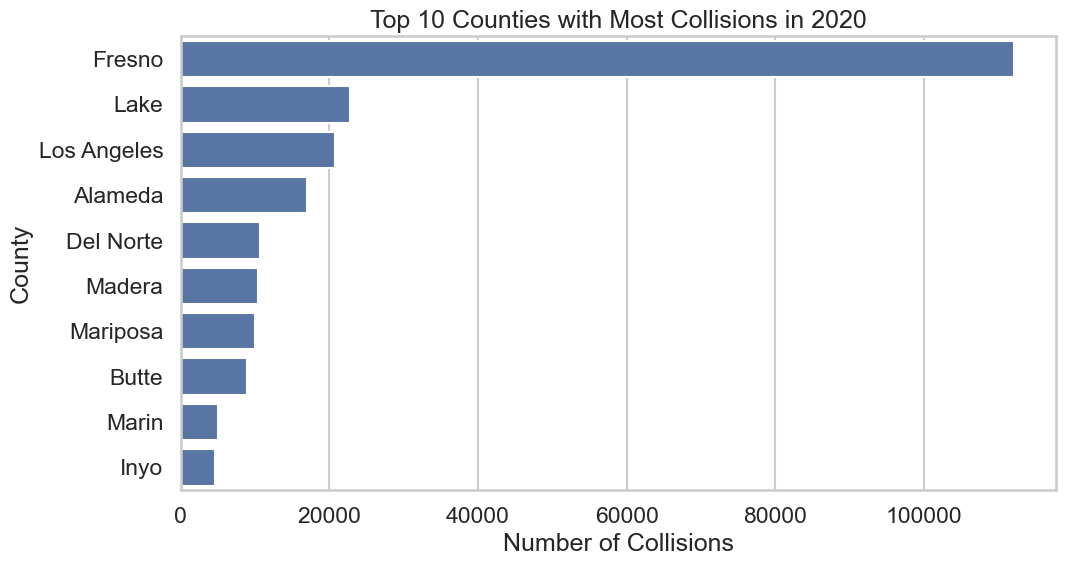

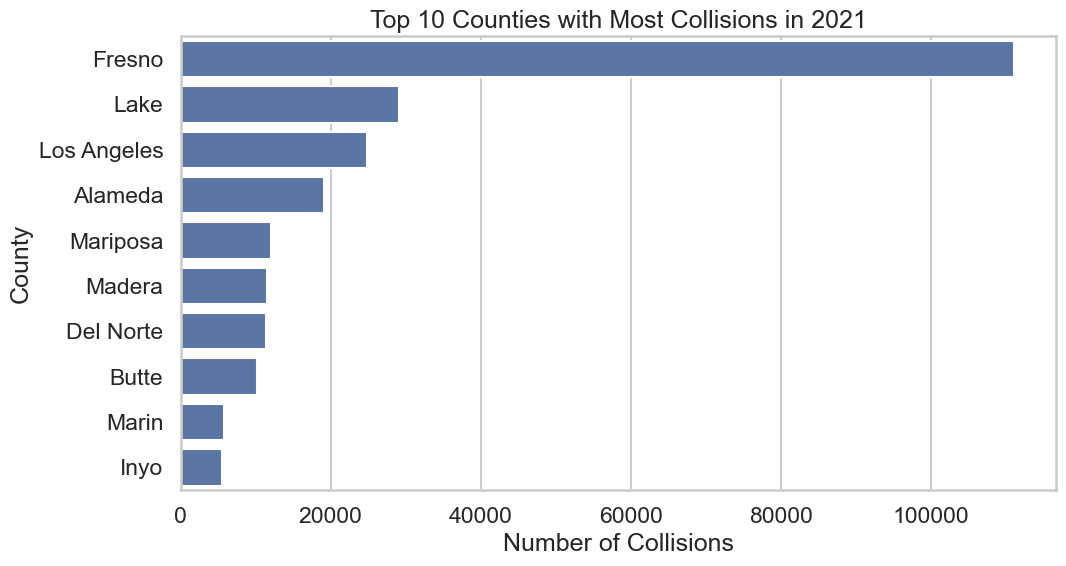

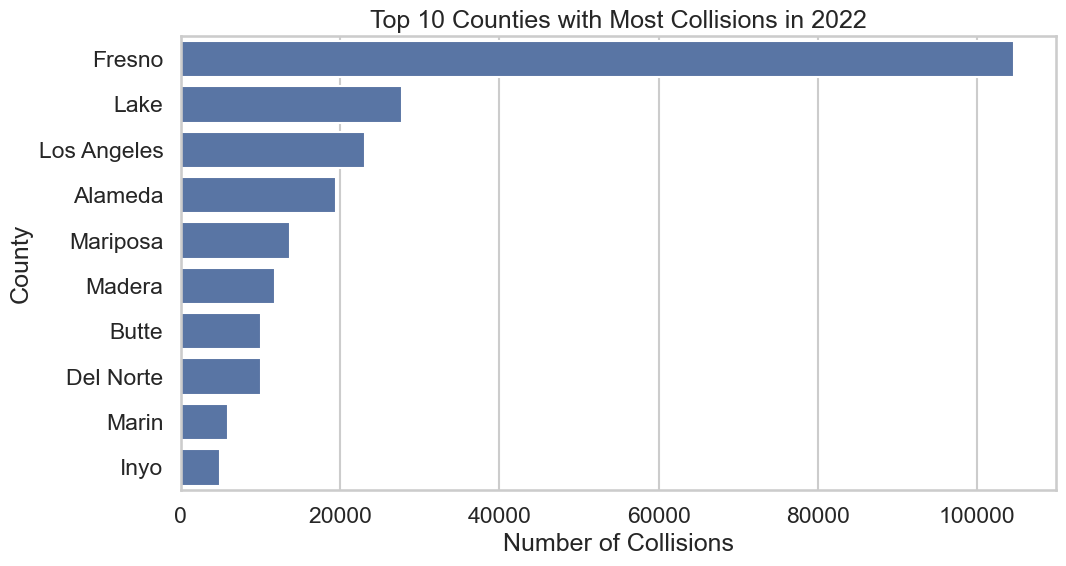

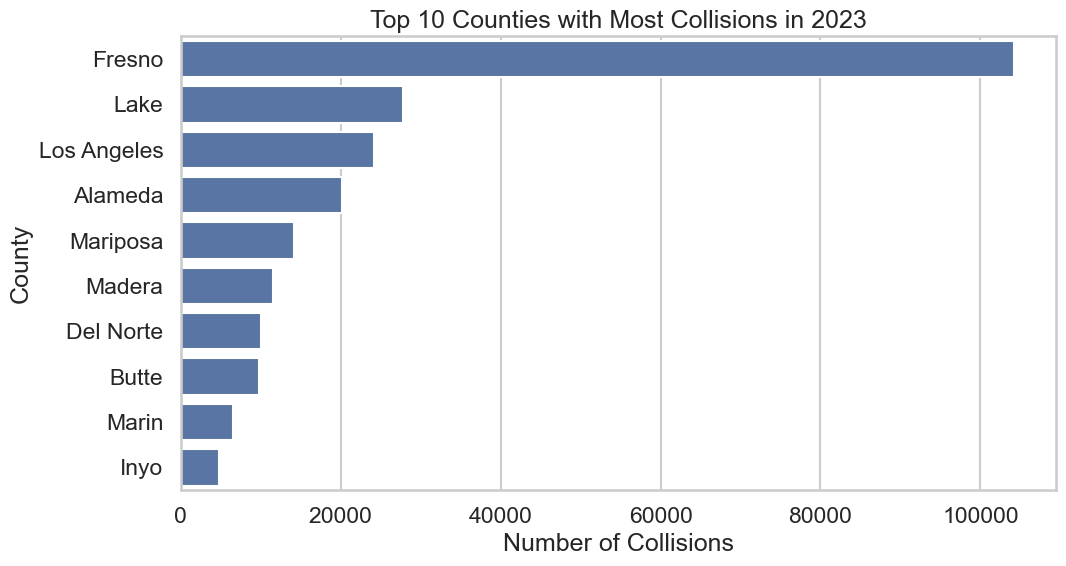

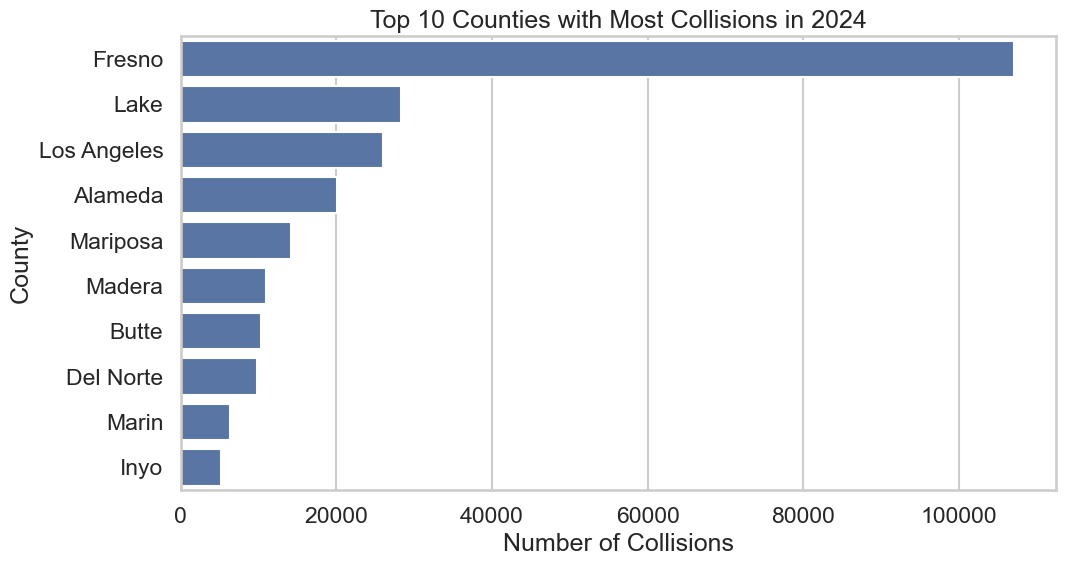

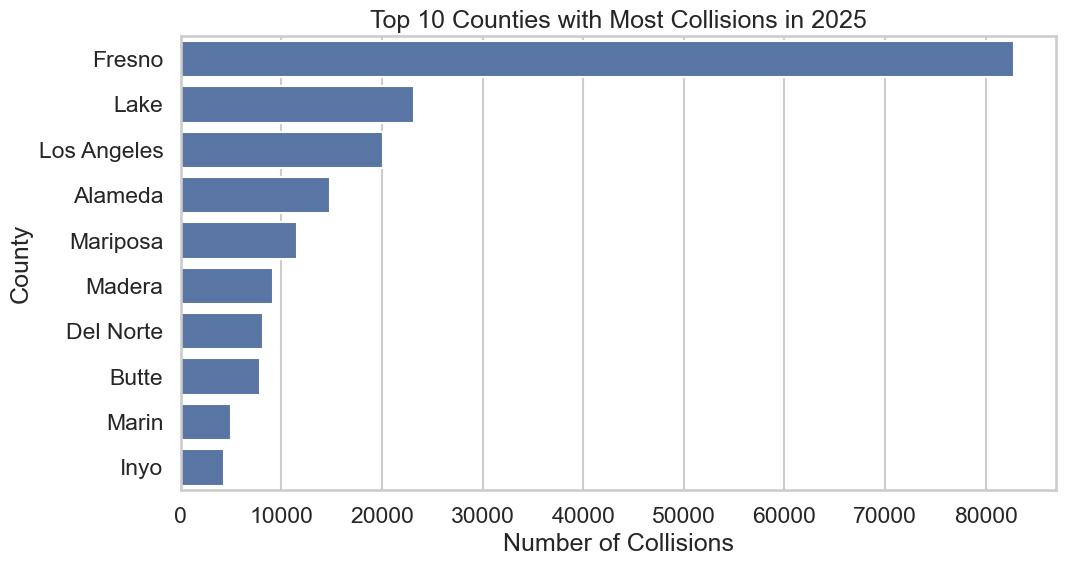

In [31]:
# =========================
# 1) Top-10 counties by number of collisions (one chart per year)
# =========================
assert {"Year","County_Name"}.issubset(c_merge.columns), "Need Year & County_Name in c_merge"

collisions_yearly = (
    c_merge.groupby(["Year","County_Name"]).size()
           .reset_index(name="num_collisions")
           .sort_values(["Year","num_collisions"], ascending=[True, False])
)

years = sorted(pd.to_numeric(c_merge["Year"], errors="coerce").dropna().unique().astype(int))
for y in years:
    top10 = collisions_yearly.query("Year == @y").head(10)
    plt.figure(figsize=(11,6))
    # Use a single color to avoid seaborn 0.14 palette+hue warnings
    sns.barplot(data=top10, x="num_collisions", y="County_Name", color=sns.color_palette()[0])
    plt.title(f"Top 10 Counties with Most Collisions in {y}")
    plt.xlabel("Number of Collisions"); plt.ylabel("County")
    plt.tight_layout(); plt.show()

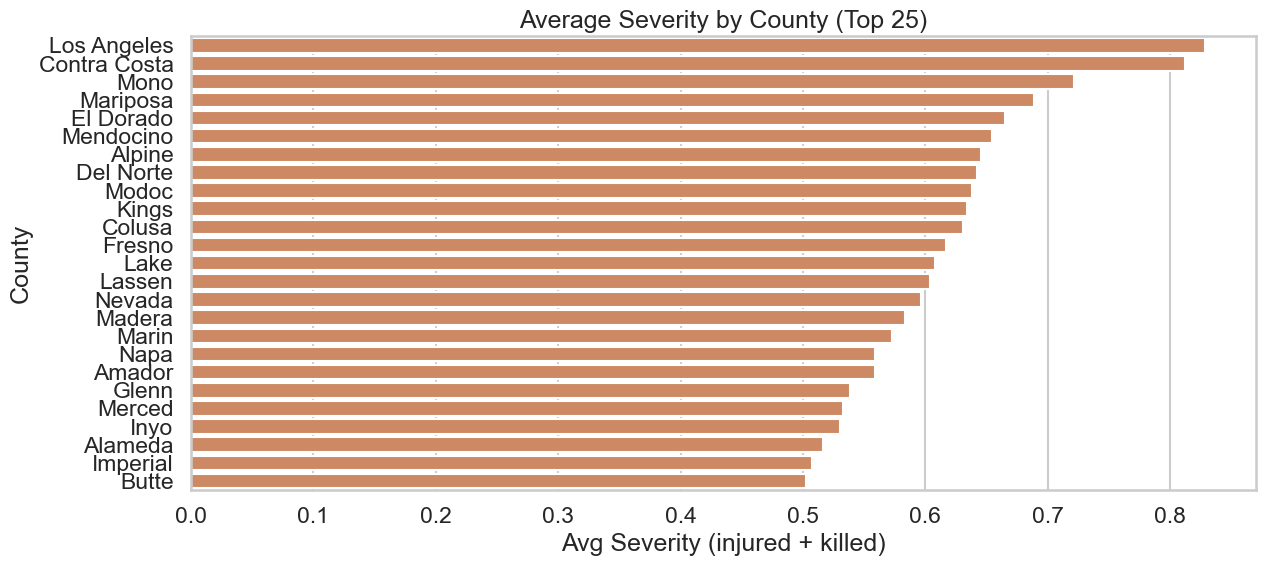

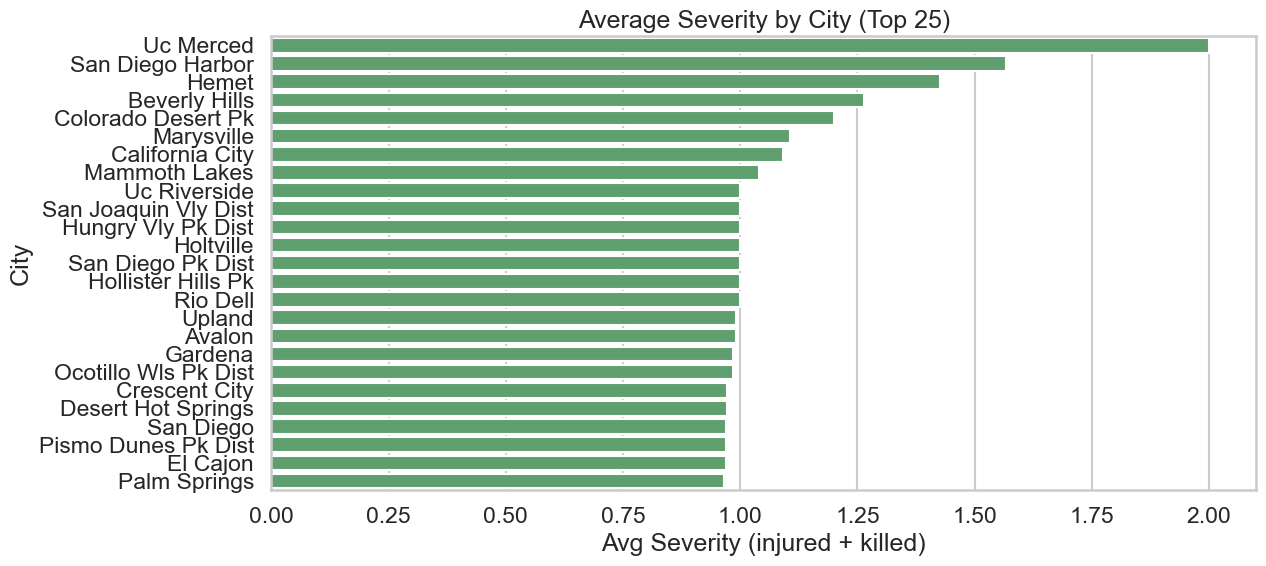

In [32]:
# =========================
# 2) Average severity by COUNTY (bar) & by CITY (bar)
# =========================
if {"County_Name","Severity_Score"}.issubset(cp_all.columns):
    sev_by_county = (cp_all.groupby("County_Name")["Severity_Score"]
                          .mean().reset_index(name="avg_severity")
                          .sort_values("avg_severity", ascending=False))
    plt.figure(figsize=(13,6))
    sns.barplot(data=sev_by_county.head(25), x="avg_severity", y="County_Name", color=sns.color_palette()[1])
    plt.title("Average Severity by County (Top 25)")
    plt.xlabel("Avg Severity (injured + killed)"); plt.ylabel("County")
    plt.tight_layout(); plt.show()

if {"City_Name","Severity_Score"}.issubset(cp_all.columns):
    sev_by_city = (cp_all.groupby("City_Name")["Severity_Score"]
                        .mean().reset_index(name="avg_severity")
                        .sort_values("avg_severity", ascending=False))
    plt.figure(figsize=(13,6))
    sns.barplot(data=sev_by_city.head(25), x="avg_severity", y="City_Name", color=sns.color_palette()[2])
    plt.title("Average Severity by City (Top 25)")
    plt.xlabel("Avg Severity (injured + killed)"); plt.ylabel("City")
    plt.tight_layout(); plt.show()

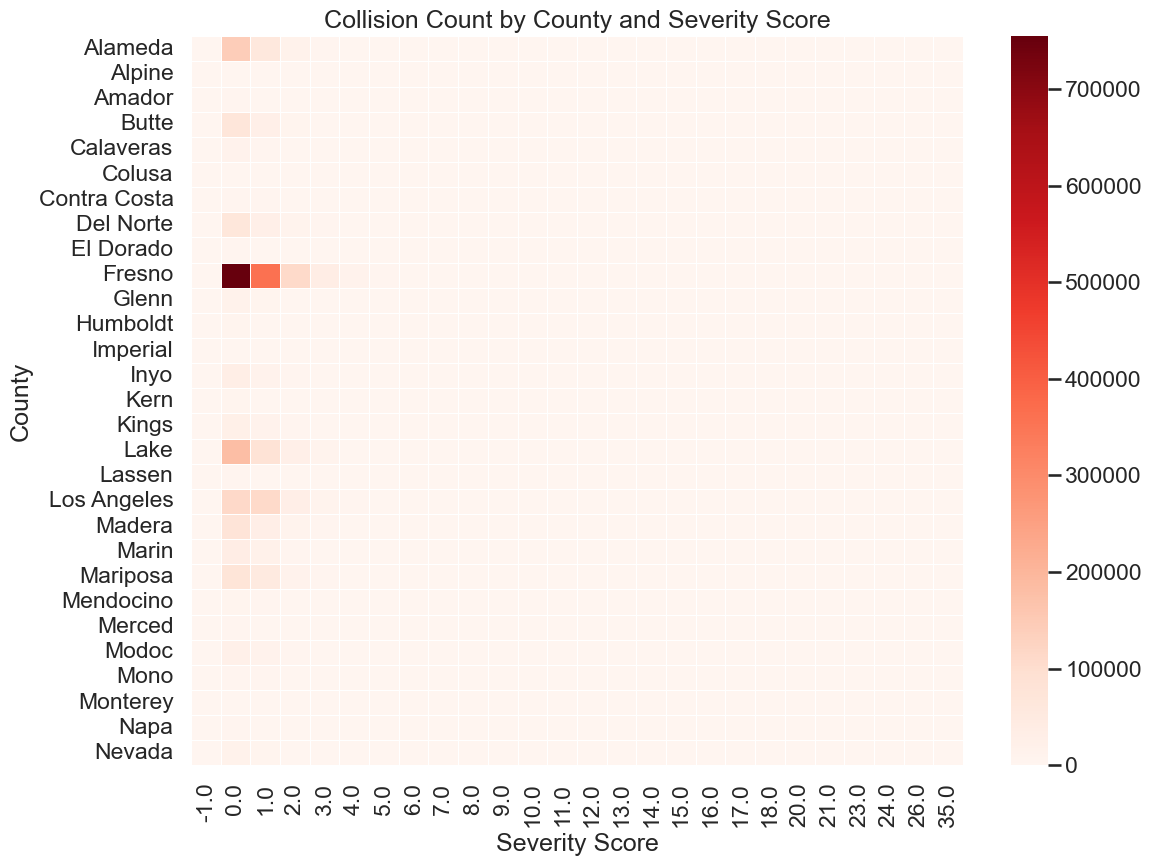

In [33]:
# =========================
# 3) County × Severity_Score heatmap (counts)
# =========================
if {"County_Name","Severity_Score"}.issubset(cp_all.columns):
    heat_df = cp_all.groupby(["County_Name","Severity_Score"]).size().unstack(fill_value=0)
    # Make severity columns sorted if numeric
    ordered_cols = sorted([c for c in heat_df.columns if isinstance(c,(int,float,np.integer,np.floating))])
    heat_df = heat_df[ordered_cols] if ordered_cols else heat_df

    plt.figure(figsize=(12,9))
    sns.heatmap(heat_df, cmap="Reds", linewidths=0.5, linecolor="white")
    plt.title("Collision Count by County and Severity Score")
    plt.xlabel("Severity Score"); plt.ylabel("County")
    plt.tight_layout(); plt.show()

In [34]:
# =========================
# 4) Gender by COUNTY and CITY (pivot tables + optional bar)
# =========================
if {"County_Name","GenderDescription"}.issubset(cp_all.columns):
    gender_by_county = cp_all.groupby(["County_Name","GenderDescription"]).size().unstack(fill_value=0)
    display(gender_by_county.head(20))  # big table; shows first 20 counties

if {"City_Name","GenderDescription"}.issubset(cp_all.columns):
    gender_by_city = cp_all.groupby(["City_Name","GenderDescription"]).size().unstack(fill_value=0)
    display(gender_by_city.head(10))

GenderDescription,FEMALE,MALE,NON-BINARY,UNKNOWN
County_Name,,,,
Alameda,61097,120766,65,3959
Alpine,1364,2477,1,35
Amador,1700,3029,2,44
Butte,33656,57123,51,3172
Calaveras,5849,11048,6,266
Colusa,700,1553,0,44
Contra Costa,3099,6423,2,70
Del Norte,30388,56217,80,6354
El Dorado,2457,4342,0,111


GenderDescription,FEMALE,MALE,NON-BINARY,UNKNOWN
City_Name,,,,
Adelanto,407,682,0,6
Agoura Hills,590,979,0,11
Alameda,2151,3303,1,772
Albany,733,1217,1,41
Alhambra,3551,5498,9,98
Aliso Viejo,570,703,0,2
Alturas,7,13,0,0
Amador City,5,7,0,0
American Canyon,438,744,1,56


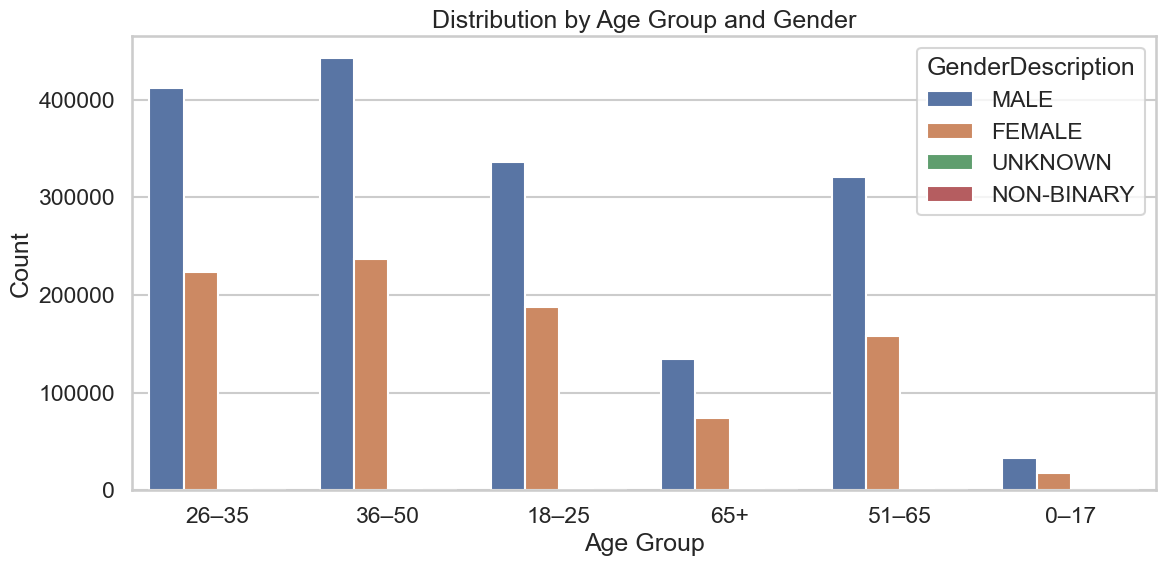

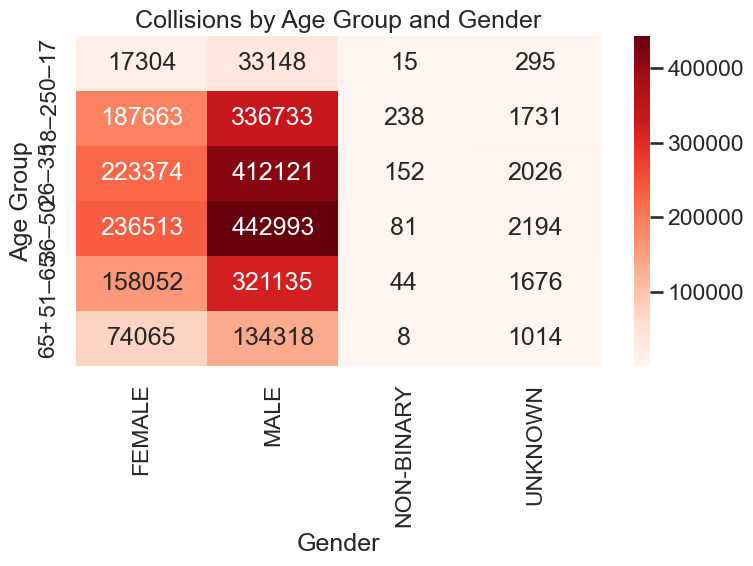

In [35]:
# =========================
# 5) Age Group × Gender — countplot + heatmap
# =========================
if {"Age_Group","GenderDescription"}.issubset(cp_all.columns):
    plt.figure(figsize=(12,6))
    sns.countplot(data=cp_all.dropna(subset=["Age_Group","GenderDescription"]),
                  x="Age_Group", hue="GenderDescription")
    plt.title("Distribution by Age Group and Gender")
    plt.xlabel("Age Group"); plt.ylabel("Count")
    plt.tight_layout(); plt.show()

    age_gender = (cp_all.dropna(subset=["Age_Group","GenderDescription"])
                        .groupby(["Age_Group","GenderDescription"]).size().unstack(fill_value=0))
    plt.figure(figsize=(8,6))
    sns.heatmap(age_gender, annot=True, fmt="d", cmap="Reds")
    plt.title("Collisions by Age Group and Gender")
    plt.xlabel("Gender"); plt.ylabel("Age Group")
    plt.tight_layout(); plt.show()

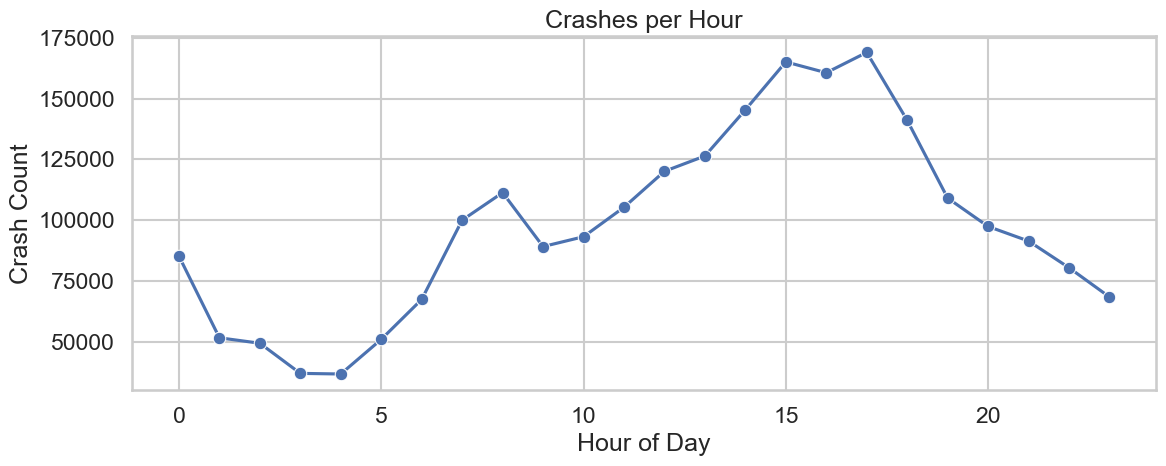

In [36]:
# =========================
# 6) Crashes per hour (frequency) & severity by hour (mean)
# =========================
if "Hour" in c_merge.columns:
    crashes_by_hour = c_merge["Hour"].value_counts().sort_index()
    plt.figure(figsize=(12,5))
    sns.lineplot(x=crashes_by_hour.index, y=crashes_by_hour.values, marker="o")
    plt.title("Crashes per Hour"); plt.xlabel("Hour of Day"); plt.ylabel("Crash Count")
    plt.tight_layout(); plt.show()

    if "Severity" in c_merge.columns:
        sev_by_hour = c_merge.groupby("Hour")["Severity"].mean()
        plt.figure(figsize=(12,5))
        sns.lineplot(x=sev_by_hour.index, y=sev_by_hour.values, marker="o")
        plt.title("Average Severity by Hour"); plt.xlabel("Hour of Day"); plt.ylabel("Average Severity")
        plt.tight_layout(); plt.show()